<a href="https://colab.research.google.com/github/Mridhu98/GIT/blob/main/Stroke_classificationmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


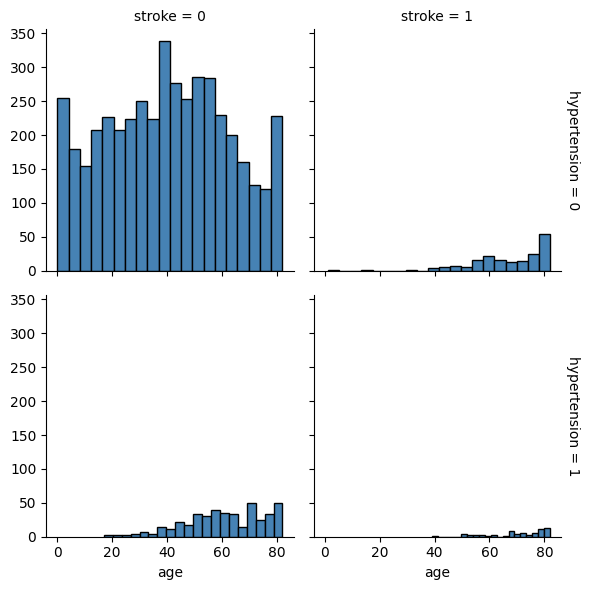

In [10]:
g = sns.FacetGrid(df, col="stroke", row='hypertension',height=3, aspect=1,
                  palette="viridis", margin_titles=True)
g.map(plt.hist, "age", bins=20, color="steelblue", edgecolor="black")

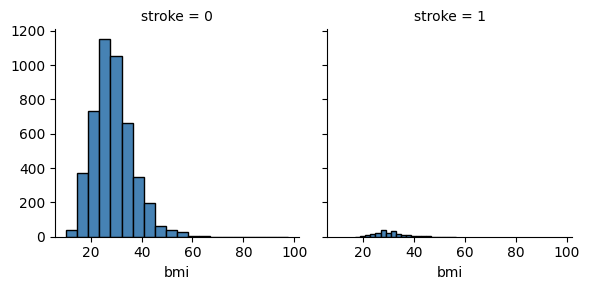

In [11]:
g = sns.FacetGrid(df, col="stroke", height=3, aspect=1,
                  palette="viridis", margin_titles=True)
g.map(plt.hist, "bmi", bins=20, color="steelblue", edgecolor="black")

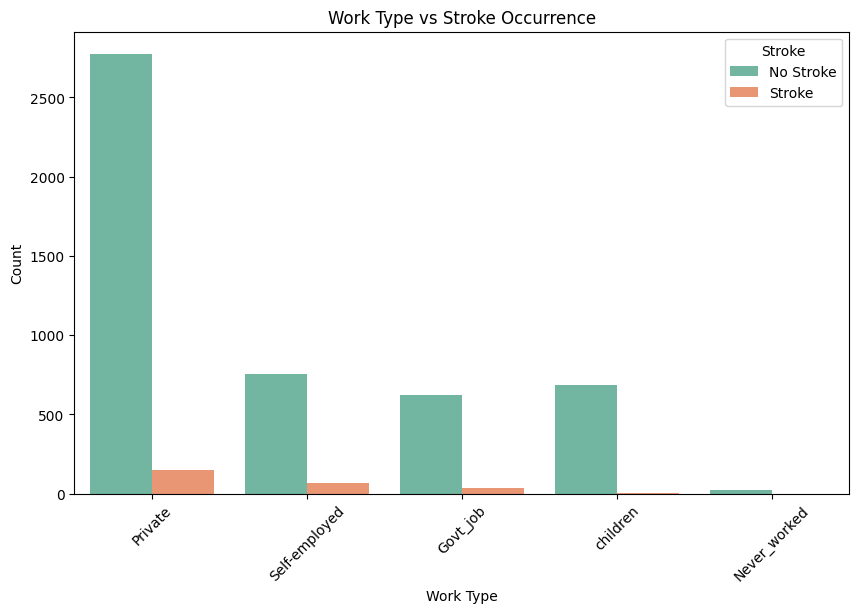

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(x='work_type', hue='stroke', data=df, palette='Set2')
plt.title('Work Type vs Stroke Occurrence')
plt.xlabel('Work Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Stroke', loc='upper right', labels=['No Stroke', 'Stroke'])
plt.show()

<Axes: xlabel='smoking_status', ylabel='count'>

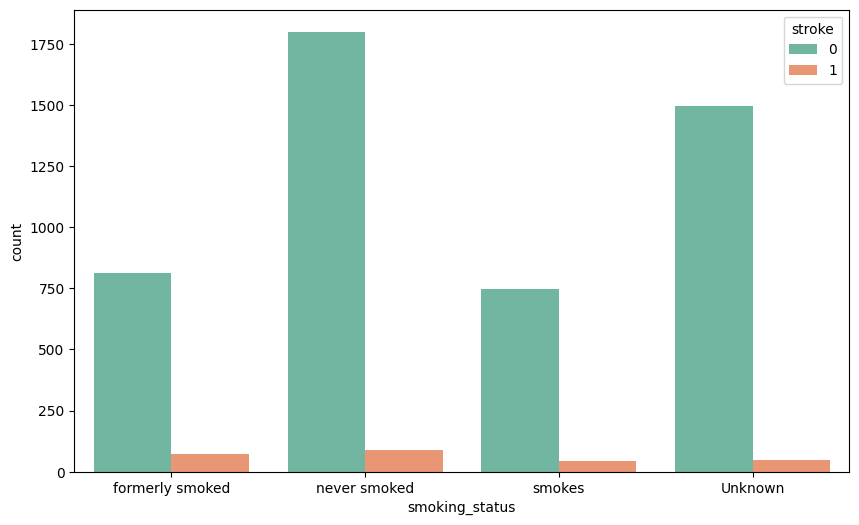

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(x='smoking_status', hue='stroke', data=df, palette='Set2')

In [14]:
# stroke numbers by unkown smoking status
display(df[df['smoking_status']=='Unknown']['stroke'].value_counts())
display(df['smoking_status'].value_counts())

print(df['smoking_status'].isnull().sum())

,count
stroke,
0,1497
1,47


,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


0


In [15]:
smoking_marking = {'formerly smoked': 1, 'never smoked': 0, 'smokes': 2, 'Unknown': 3}
df['smoking_status'] = df['smoking_status'].map(smoking_marking)
df['smoking_status']

,smoking_status
0,1
1,0
2,0
3,2
4,0
...,...
5105,0
5106,0
5107,0
5108,1


In [16]:
mean_bmi = df['bmi'].mean()
df['bmi'] = df['bmi'].fillna(mean_bmi)
df['bmi'].isnull().sum()

np.int64(0)

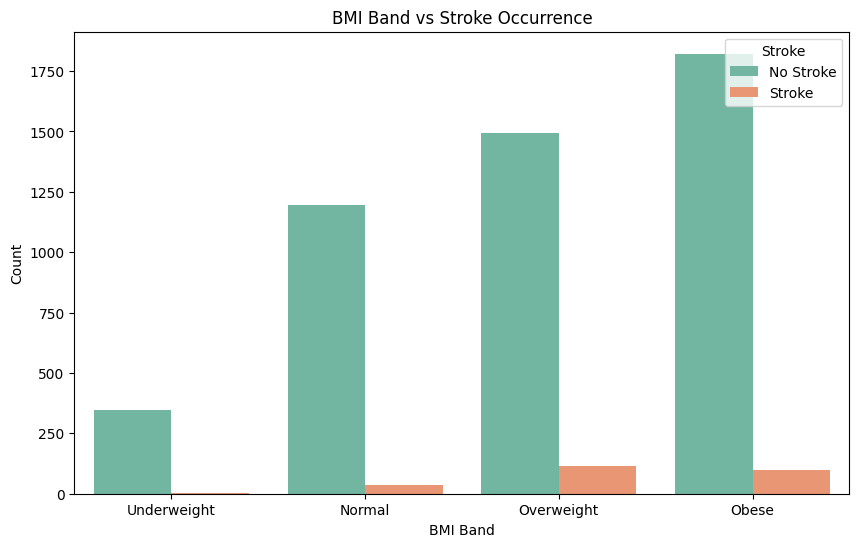

In [17]:
df['bmiBand'] = pd.cut(df['bmi'], bins=[0,18.5,24.9,29.9,100],labels=['Underweight','Normal','Overweight','Obese'])
plt.figure(figsize=(10,6))
sns.countplot(x='bmiBand', hue='stroke', data=df, palette='Set2')
plt.title('BMI Band vs Stroke Occurrence')
plt.xlabel('BMI Band')
plt.ylabel('Count')
plt.legend(title='Stroke', loc='upper right', labels=['No Stroke', 'Stroke'])
plt.show()

In [18]:
bmi_marking = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
df['bmiBand'] = df['bmiBand'].map(bmi_marking)
df['bmiBand']

,bmiBand
0,3
1,2
2,3
3,3
4,1
...,...
5105,2
5106,3
5107,3
5108,2


In [19]:
residence_dummies = pd.get_dummies(df['Residence_type'], drop_first=True, prefix='Residence')
residence_dummies = residence_dummies.astype(int)
df = pd.concat([df, residence_dummies], axis=1)
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmiBand,Residence_Urban
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,1,1,3,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,0,1,2,0
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,0,1,3,0
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,2,1,3,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,0,1,1,0
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.000000,1,1,2,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.400000,0,1,2,0
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.800000,0,1,1,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.893237,3,1,2,0
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.200000,3,1,1,1


In [20]:
df.drop('Residence_type', axis=1, inplace=True)

In [21]:
married_marking = {'Yes': 1, 'No': 0}
df['ever_married'] = df['ever_married'].map(married_marking)
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,avg_glucose_level,bmi,smoking_status,stroke,bmiBand,Residence_Urban
0,9046,Male,67.0,0,1,1,Private,228.69,36.600000,1,1,3,1
1,51676,Female,61.0,0,0,1,Self-employed,202.21,28.893237,0,1,2,0
2,31112,Male,80.0,0,1,1,Private,105.92,32.500000,0,1,3,0
3,60182,Female,49.0,0,0,1,Private,171.23,34.400000,2,1,3,1
4,1665,Female,79.0,1,0,1,Self-employed,174.12,24.000000,0,1,1,0
5,56669,Male,81.0,0,0,1,Private,186.21,29.000000,1,1,2,1
6,53882,Male,74.0,1,1,1,Private,70.09,27.400000,0,1,2,0
7,10434,Female,69.0,0,0,0,Private,94.39,22.800000,0,1,1,1
8,27419,Female,59.0,0,0,1,Private,76.15,28.893237,3,1,2,0
9,60491,Female,78.0,0,0,1,Private,58.57,24.200000,3,1,1,1


In [22]:
work_type_dummies = pd.get_dummies(df['work_type'], drop_first=True, prefix='workType', dtype=int)
df = pd.concat([df, work_type_dummies], axis=1)
df.drop('work_type', axis=1, inplace=True)
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,smoking_status,stroke,bmiBand,Residence_Urban,workType_Never_worked,workType_Private,workType_Self-employed,workType_children
0,9046,Male,67.0,0,1,1,228.69,36.600000,1,1,3,1,0,1,0,0
1,51676,Female,61.0,0,0,1,202.21,28.893237,0,1,2,0,0,0,1,0
2,31112,Male,80.0,0,1,1,105.92,32.500000,0,1,3,0,0,1,0,0
3,60182,Female,49.0,0,0,1,171.23,34.400000,2,1,3,1,0,1,0,0
4,1665,Female,79.0,1,0,1,174.12,24.000000,0,1,1,0,0,0,1,0
5,56669,Male,81.0,0,0,1,186.21,29.000000,1,1,2,1,0,1,0,0
6,53882,Male,74.0,1,1,1,70.09,27.400000,0,1,2,0,0,1,0,0
7,10434,Female,69.0,0,0,0,94.39,22.800000,0,1,1,1,0,1,0,0
8,27419,Female,59.0,0,0,1,76.15,28.893237,3,1,2,0,0,1,0,0
9,60491,Female,78.0,0,0,1,58.57,24.200000,3,1,1,1,0,1,0,0


In [29]:
gender_marking = {'Male' : 1, 'Female' : 0, 'Other' : 2}
df['gender'] = df['gender'].map(gender_marking)
df['gender'].fillna(2, inplace=True) # Fill any unmapped NaNs with 'Other' category (2)

/tmp/ipython-input-3020122471.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(2, inplace=True) # Fill any unmapped NaNs with 'Other' category (2)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC,  LinearSVC

best_accuracy = 0
best_model_name = None
best_model_pipe = None

models = {
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=300, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVC': SVC(),
    'LinearSVC': LinearSVC(max_iter=10000)
}
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('classifier', model)
    ])

    pipe.fit(X_train, y_train)
    accuracy = pipe.score(X_test, y_test)
    results[name] = accuracy

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name
        best_model_pipe = pipe
print("Model Accuracies:")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")
print(f"\nBest Model: {best_model_name} with accuracy: {best_accuracy:.4f}")

Model Accuracies:
KNeighborsClassifier: 0.9481
GaussianNB: 0.3141
RandomForestClassifier: 0.9491
LogisticRegression: 0.9521
SVC: 0.9511
LinearSVC: 0.9511

Best Model: LogisticRegression with accuracy: 0.9521


In [32]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = best_model_pipe.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[972   0]
 [ 49   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

